In [12]:
import os
import random
import pandas as pd
folder_path_1 = '/root/PetImages/cats'
petlist = []
for item in os.listdir(folder_path_1):
    petlist.append([f'cats/{item}'])

random.shuffle(petlist)
df = pd.DataFrame(petlist, columns=['Images'])
df.to_csv("output_cat.csv", index=False)

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from tqdm import tqdm # 进度条
from torchvision import transforms
from torchvision.utils import save_image
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import os
import time
import torch
import torch.nn as nn
import pandas as pd
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torch.nn.functional import relu
from PIL import Image
from torchvision import models

In [2]:
class Cats(Dataset):
    def __init__(self,csv_file, root_dir, transform = None, index_range = None):
        self.annotations = pd.read_csv(os.path.join(root_dir,csv_file))
        self.root_dir = root_dir
        self.transform = transform
        if index_range is not None:
            self.annotations = self.annotations.iloc[index_range]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self,idx):
        img_path = os.path.join(self.root_dir,self.annotations.iloc[idx,0])
        
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error reading {img_path}: {e}")
            image = Image.new("RGB", (64,64))
    
        if self.transform:
            image = self.transform(image)   
    
        return image


In [3]:
def create_dataset():
    total_len = len(pd.read_csv('/root/output_cat.csv'))
    transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    # transforms.Normalize([0.5,0.5,0.5],
    #                      [0.5,0.5,0.5])
])
    dataset = Cats(csv_file='output_cat.csv',root_dir='/root/PetImages',transform = transform,index_range = range(0,12500))
    return dataset

In [4]:
dataset = create_dataset()

data_loader = torch.utils.data.DataLoader(dataset=dataset, batch_size = 64,
                                          shuffle=True,num_workers=2)

In [5]:
dataset[2].shape

torch.Size([3, 64, 64])

In [6]:
# ======================
# VAE MODEL
# ======================
class VAE(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()

        # ===== Encoder =====
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 64 → 32
            nn.ReLU(),

            nn.Conv2d(32, 64, 4, 2, 1),  # 32 → 16
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1), # 16 → 8
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1),# 8 → 4
            nn.ReLU(),

            nn.Conv2d(256, 512, 4, 2, 1),# 4 → 2
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(512*2*2, z_dim)
        self.fc_logvar = nn.Linear(512*2*2, z_dim)

        self.fc_decode = nn.Linear(z_dim, 512*2*2)

        # ===== Decoder =====
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), # 2 → 4
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 4 → 8
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8 → 16
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 16 → 32
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 32 → 64
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 512, 2, 2)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [13]:
# 带卷积的VAE
class VAE(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3,32,4,2,1),   # 112
            nn.ReLU(),
            nn.Conv2d(32,64,4,2,1),  # 56
            nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), # 28
            nn.ReLU(),
            nn.Conv2d(128,256,4,2,1),# 14
            nn.ReLU(),
            nn.Conv2d(256,512,4,2,1),# 14
            nn.ReLU(),
            nn.Conv2d(512,1024,4,2,1),# 14
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(1024*3*3, z_dim)
        self.fc_var = nn.Linear(1024*3*3, z_dim)
        self.fc_decode = nn.Linear(z_dim,1024*3*3)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(1024,512,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(512,256,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(256,128,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,3,4,2,1),
            nn.Sigmoid()
        )
    def encode(self,x):
        h = self.encoder(x)
        h = h.view(h.size(0),-1)
        return self.fc_mu(h), self.fc_var(h)

    def reparameterize(self,mu,var):
        std = torch.exp(0.5*var)
        eps = torch.randn_like(std)
        return mu + eps*std
    
    def decode(self,z):
        h = self.fc_decode(z)
        h = h.view(-1,1024,3,3)
        return self.decoder(h)
    
    def forward(self,x):
        mu,var = self.encode(x)
        z = self.reparameterize(mu,var)
        return self.decode(z),mu,var

In [9]:
class VAE(nn.Module):
    def __init__(self,image_size = 64*64*3,h_dim = 2048, z_dim = 128):
        # z_dim = 信息压缩强度，太小：丢掉很多信息 太大：容易过拟合
        # h_dim = 网络表达能力，太小：提取信息的能力不足，太大：直接记住训练集
        super().__init__()
        self.fc1 = nn.Linear(image_size, h_dim)
        self.fc2 = nn.Linear(h_dim, z_dim)
        self.fc3 = nn.Linear(h_dim, z_dim)
        self.fc4 = nn.Linear(z_dim, h_dim)
        self.fc5 = nn.Linear(h_dim, image_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self,x):
        x = self.relu(self.fc1(x))
        return self.fc2(x), self.fc3(x)

    def reparameterize(self,mu,var):
        std = torch.exp(0.5*var)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self,z):
        h = self.relu(self.fc4(z))
        return self.sigmoid(self.fc5(h))

    def forward(self,x):
        mu,var = self.encode(x)
        z = self.reparameterize(mu,var)
        return self.decode(z),mu,var

In [ ]:
# 带Resnet的VAE
class bottle(nn.Module):
    super().__init__()
    def __init__(self,in_channel,out_channel,stride=1):
        self.conv1 = nn.Conv2d(in_channel,out_channel,kernel_size=3,stride=stride,padding=1,bias=False)
        self.bn1 = nn.BatchNorm2d(out_channel)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channel,out_channel,kernel_size=3,stride=stride,padding=1,bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv3 = nn.Conv2d(out_channel,out_channel,kernel_size=3,stride=stride,padding=1,bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channel != out_channel:
            self.shortcut = nn.Sequential(nn.Conv2d(in_channel,out_channel,kernel_size=1,stride=stride,padding=1,bias=False),
                                         nn.BatchNorm2d(out_channel))

    def forward(self,x):
        identity = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = x + identity
        x = self.relu(x)
        return x

class Resnet(nn.Module):
    super().__init__()
    def __init__(self,):
        self.in_channels = 3
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = self._make_layer(block,num_block[0],64)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = self._make_layer(block,num_block[1],128)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = self._make_layer(block,num_block[2],256)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = self._make_layer(block,num_block[3],512)
        self.bn4 = nn.BatchNorm2d(512)
        self.relu = nn.ReLU()

    def _make_layer(self,block,num_block,out_channels):
        layers = []
        layers.append(block(self.in_channels,out_channels,stride))
        self.in_channels = out_channels
        for _ in range(1,num_block):
            layers.append(block(self.in_channels,out_channels,stride))
        return nn.Sequential(*layers)

    def forward(self,x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.avgpool(x)
        return x

In [7]:
def loss_function(recon_x, x, mu, logvar, beta):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + beta * kl

In [8]:
model = VAE().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
epoch_losses = []
epochs = 50

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    # 🔥 KL权重逐渐变大（核心）
    beta = min(1.0, epoch / 10)

    for images in data_loader:
        images = images.cuda()

        recon, mu, logvar = model(images)
        loss = loss_function(recon, images, mu, logvar, beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(data_loader):.2f}, beta={beta:.3f}")

Error reading /root/PetImages/cats/.ipynb_checkpoints: [Errno 21] Is a directory: '/root/PetImages/cats/.ipynb_checkpoints'
Epoch 1, Loss: 34554.38, beta=0.000
Error reading /root/PetImages/cats/.ipynb_checkpoints: [Errno 21] Is a directory: '/root/PetImages/cats/.ipynb_checkpoints'
Epoch 2, Loss: 20295.35, beta=0.100
Error reading /root/PetImages/cats/.ipynb_checkpoints: [Errno 21] Is a directory: '/root/PetImages/cats/.ipynb_checkpoints'
Epoch 3, Loss: 18511.09, beta=0.200
Error reading /root/PetImages/cats/.ipynb_checkpoints: [Errno 21] Is a directory: '/root/PetImages/cats/.ipynb_checkpoints'
Epoch 4, Loss: 17389.11, beta=0.300
Error reading /root/PetImages/cats/.ipynb_checkpoints: [Errno 21] Is a directory: '/root/PetImages/cats/.ipynb_checkpoints'
Epoch 5, Loss: 16653.66, beta=0.400
Error reading /root/PetImages/cats/.ipynb_checkpoints: [Errno 21] Is a directory: '/root/PetImages/cats/.ipynb_checkpoints'
Epoch 6, Loss: 16375.37, beta=0.500
Error reading /root/PetImages/cats/.ipyn

In [16]:
epoch_losses = []
for epoch in range(100):
    epoch_loss = 0
    for images in data_loader:

        images = images.cuda()

        x_reconst, mu, var = model(images)

        loss = loss_function(x_reconst,images,mu,var)

        # reconst_loss = F.mse_loss(x_reconst, images)
        # kl_div = -0.5 * torch.sum(1 + var - mu.pow(2) - var.exp())

        # loss = reconst_loss + 0.05 * kl_div

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    avg_epoch_loss = epoch_loss / len(data_loader)
    epoch_losses.append(avg_epoch_loss)
    print(f'Epoch {epoch + 1}, Average Loss: {avg_epoch_loss:.4f}')

Error reading /root/PetImages/cats/.ipynb_checkpoints: [Errno 21] Is a directory: '/root/PetImages/cats/.ipynb_checkpoints'


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x1024 and 9216x256)

In [9]:
with torch.no_grad():

    z = torch.randn(64,128).to()

    samples = model.fc_decode(z)
    samples = samples.view(-1,256,4,4)
    samples = model.decoder(samples)
    save_image(samples, '/root/vae_result.png')

NameError: name 'device' is not defined

In [11]:
# 训练完成后保存图像
with torch.no_grad():
    # 保存采样图像，即潜在向量Z通过解码器生成的新图像
    z = torch.randn(64,128).cuda()

    out = model.decode(z)
    
    out = (out + 1) / 2
    
    save_image(out,'/root/vae_image.png')
    # z = torch.randn(64,128).cuda()
    # out = model.decode(z).view(-1, 3, 64, 64)
    # out = (out + 1) / 2
    # save_image(out, '/root/vae_image.png')

    # 保存重构图像，即原图像通过解码器生成的图像
    images = next(iter(data_loader)).cuda()
    #images = next(iter(data_loader))[0].reshape(-1, 64*64*3).cuda()
    out, _, _ = model(images)
    x_concat = torch.cat([images, out], dim=3)
    save_image(x_concat, '/root/vae_result.png')

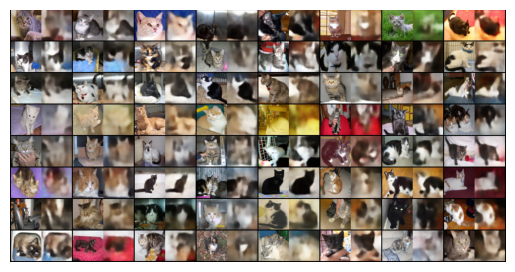

In [12]:
reconsPath = '/root/vae_result.png'
Image = mpimg.imread(reconsPath)
plt.imshow(Image)  # 显示图像
plt.axis('off')  # 不显示坐标轴
plt.show()
